In [27]:
! pip install langchain langchain-openai langchain-community langgraph python-dotenv faiss-cpu pypdf

In [28]:
from langchain_groq import ChatGroq
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.prebuilt import ToolNode, tools_condition

In [29]:
load_dotenv()

True

In [ ]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [31]:
loader=PyPDFLoader("document.pdf")
docs=loader.load()

In [32]:
len(docs)

66

In [33]:
spiltter=RecursiveCharacterTextSplitter(chunk_size=2000, chunk_overlap=200)
chunks=spiltter.split_documents(docs)

In [34]:
len(chunks)

70

In [35]:
embeddings=GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vector_store=FAISS.from_documents(chunks,embeddings)

In [36]:
vector_store

In [37]:
retriever=vector_store.as_retriever(search_type='similarity',search_kwargs={'k':4})

In [38]:
retriever.invoke("What is Reinforcement learning")

[Document(id='2185cd29-00cd-4e5b-a780-ea6e6348afb7', metadata={'producer': 'Microsoft® Word for Microsoft 365', 'creator': 'Microsoft® Word for Microsoft 365', 'creationdate': '2022-11-17T07:54:22+05:30', 'author': 'ksingh@ycce.edu', 'moddate': '2022-11-17T07:54:22+05:30', 'source': 'document.pdf', 'total_pages': 66, 'page': 65, 'page_label': '66'}, page_content='6 What is need of Reinforcement learning? \n Reinforcement Learning (RL) corrects all three drawbacks of the traditional \napproach. First, RL requires very little programmer effort, because most of the \nwork is done by a process of automatic training, not programming. Second, if the \nenvironment changes, the training can be re -run, without any additional \nprogramming. In fact, retraining can be done continuously, online, as the system \nruns. Third, RL is mathematically guaranteed to converge to an optimal policy. \n7 Outline different ways of model combination schemes. \n There are different ways the multiple base-learne

In [39]:
@tool
def rag_tool(query):
    """
    Retrieve relevant explanations of the PDF document.
    Uses this tool when the user asks factual/conceptual questions
    that might be answered from the store documents
    """
    result= retriever.invoke(query)

    context=[doc.page_content for doc in result]
    metadata=[doc.metadata for doc in result]

    return{
        'query':query,
        'context':context,
        'metadata':metadata
    }

In [40]:
tools = [rag_tool]
llm_with_tools=llm.bind_tools(tools)

In [41]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [42]:
def chat_node(state:ChatState):

    messages= state['messages']

    response= llm_with_tools.invoke(messages)
    return {'messages':[response]}

In [43]:
tool_node=ToolNode(tools)

In [45]:
graph= StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition)
graph.add_edge('tools','chat_node')

chatbot=graph.compile()

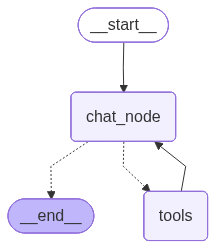

In [46]:
chatbot

In [47]:
result=chatbot.invoke(
    {
        "messages":[
            HumanMessage(content="Using the pdf notes, explain how to find the ideal value of k in KNN")
        ]
    }
)

In [48]:
result

{'messages': [HumanMessage(content='Using the pdf notes, explain how to find the ideal value of k in KNN', additional_kwargs={}, response_metadata={}, id='8bc5240e-f7a1-4ae7-8c72-17f57ae774c1'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'jxcdt6yv4', 'function': {'arguments': '{"query":"ideal value of k in KNN"}', 'name': 'rag_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 274, 'total_tokens': 295, 'completion_time': 0.054077919, 'completion_tokens_details': None, 'prompt_time': 0.015686389, 'prompt_tokens_details': None, 'queue_time': 0.053374841, 'total_time': 0.069764308}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f38cb-3ce9-7572-80b3-42926bd6d064-0', tool_calls=[{'name': 'rag_tool', 'args': {'query': 'ideal value of k in KNN'}, 'id': 'jxcdt6yv4', 'type': 'tool_call'}], i

In [49]:
print(result['messages'][-1].content)

The ideal value of k in KNN can be determined by considering the trade-off between bias and variance. A small value of k may result in overfitting, while a large value of k may result in underfitting. The choice of k depends on the specific problem and dataset. 

In general, a good starting point for k is to use a small odd number, such as 3 or 5, and then adjust as needed based on the performance of the model. It's also important to consider the distance metric used, such as Euclidean or city block distance, as well as the handling of ties.

Additionally, techniques such as cross-validation can be used to evaluate the performance of the model with different values of k and choose the one that results in the best performance. 

It's also worth noting that the value of k can be determined using various methods such as:

* Grid search: trying out different values of k and selecting the one that results in the best performance.
* Cross-validation: using a subset of the data to evaluate th